In July 2026, a 30-day experiment was conducted to evaluate the implementation of a **new AI-powered recommendation model on the homepage**. The new model was designed to deliver more personalized product recommendations based on users’ preferences.

**Experiment duration: 30 days**

# **1. Metrics Analysis**

The goal of the new recommendation system is to provide users with more relevant product suggestions at the product impression stage.

Using the metric tree, we will define the key product success metrics that may be affected by the experiment:


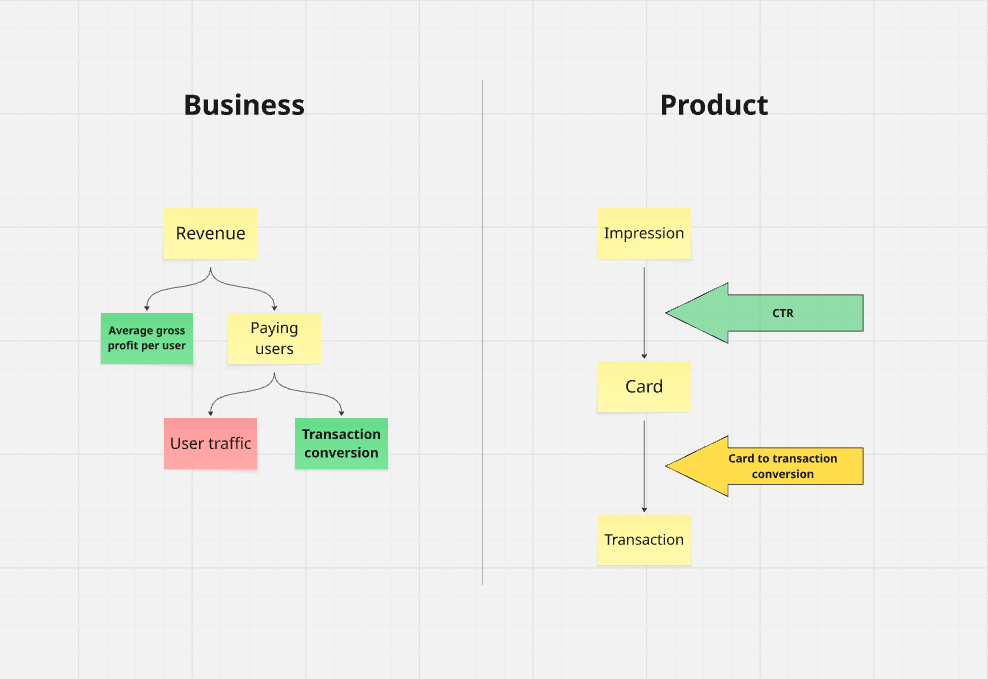

* The primary business metric is **Average GMV per User**.
* The primary product metric is **Impression-to-Purchase Conversion Rate**.
* The experiment’s target metric is **Impression-to-Click Conversion Rate (CTR)**.

We will also introduce additional monitoring metrics to provide a more comprehensive view of the experiment’s impact.

| Role      | Metric                                   | Aspect of the Experiment                          |
| --------- | ---------------------------------------- | ------------------------------------------------- |
| Primary   | Gross Margin per User                    | Overall financial impact                          |
| Target    | Recommendation CTR                       | Early indicator of recommendation relevance       |
| Proxy     | User-to-Purchase Conversion Rate         | Impact of recommendations on purchasing behaviour |
| Proxy     | Share of Users with Two or More Orders   | Early indicator of repeat purchasing behaviour    |
| Guardrail | Product Card-to-Purchase Conversion Rate | Comparison against the baseline conversion rate   |
| Guardrail | Return Rate                              | Quality and relevance of completed purchases      |
| Guardrail | Support Tickets per 100 Orders           | Frequency of customer experience issues           |



# **2. EDA**

In [6]:
import sqlalchemy
import pandas as pd
from sqlalchemy import text
import seaborn as sns
import matplotlib.pyplot as plt

from db_conn import create_engine_custom

# Connecting to the DB
DB_name = 'market_flow'
engine, _ = create_engine_custom(DB_name)

market_flow DB exists already


## **User base analysis**

First, to get some notion of the data, let's visualise basic information on users

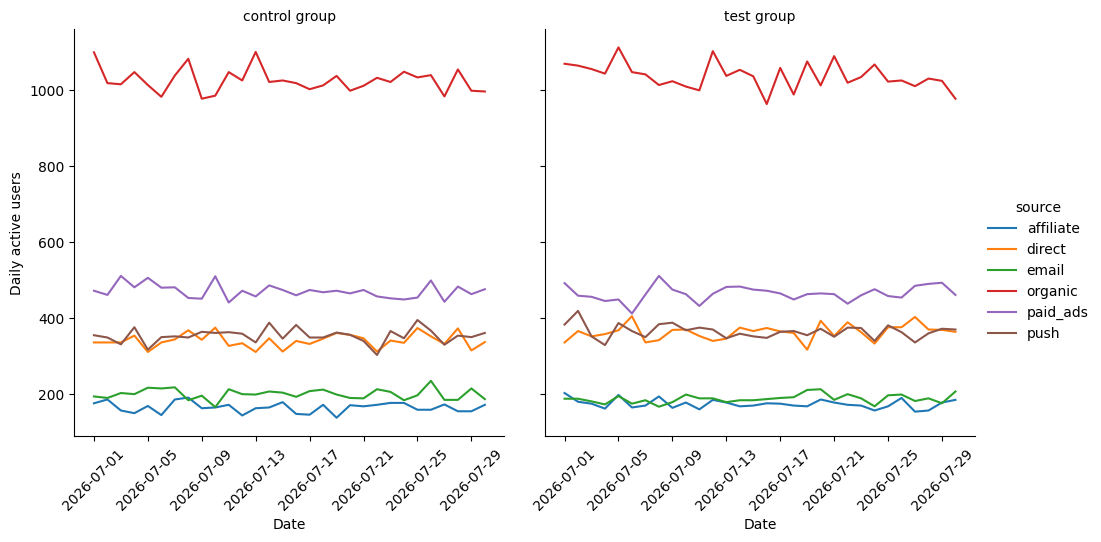

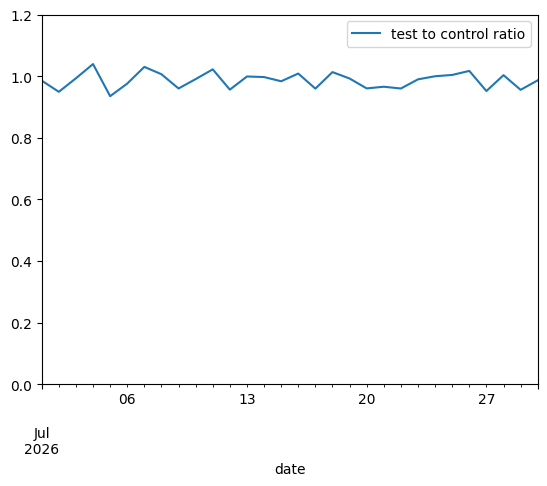

In [7]:

# Traffic distribution

with engine.connect() as conn:
    result = pd.read_sql(text("""
        SELECT 
            s.session_date as date,
            eu.experiment_group as group,
            u.traffic_source as source,
            COUNT(DISTINCT u.user_id) as num_users,
            COUNT(DISTINCT s.session_id) as num_sessions
        FROM sessions s
        JOIN experiment_assignment eu
            ON eu.user_id = s.user_id
        JOIN users u
            ON s.user_id = u.user_id
        GROUP BY s.session_date, eu.experiment_group, u.traffic_source
    """), conn)
    
g = sns.relplot(
    data=result,
    x='date',
    y='num_users',
    hue='source',
    kind='line',
    col='group'
)

g.set_axis_labels('Date', "Daily active users")
g.set_titles ('{col_name} group')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

test_to_ctrl_ratio = (result.groupby(['date', 'group'])
    .agg(test=('num_users', 'sum')).
    pivot_table(values='test',
                index='date',
                columns='group'))

test_to_ctrl_ratio['test to control ratio'] = test_to_ctrl_ratio['control'] / test_to_ctrl_ratio['test']
test_to_ctrl_ratio.plot(y='test to control ratio', kind='line',ylim=(0,1.2));

It is quite visible, that the split for the experiment was conducted properly. The amount of users is regularly equal throughout the timeline

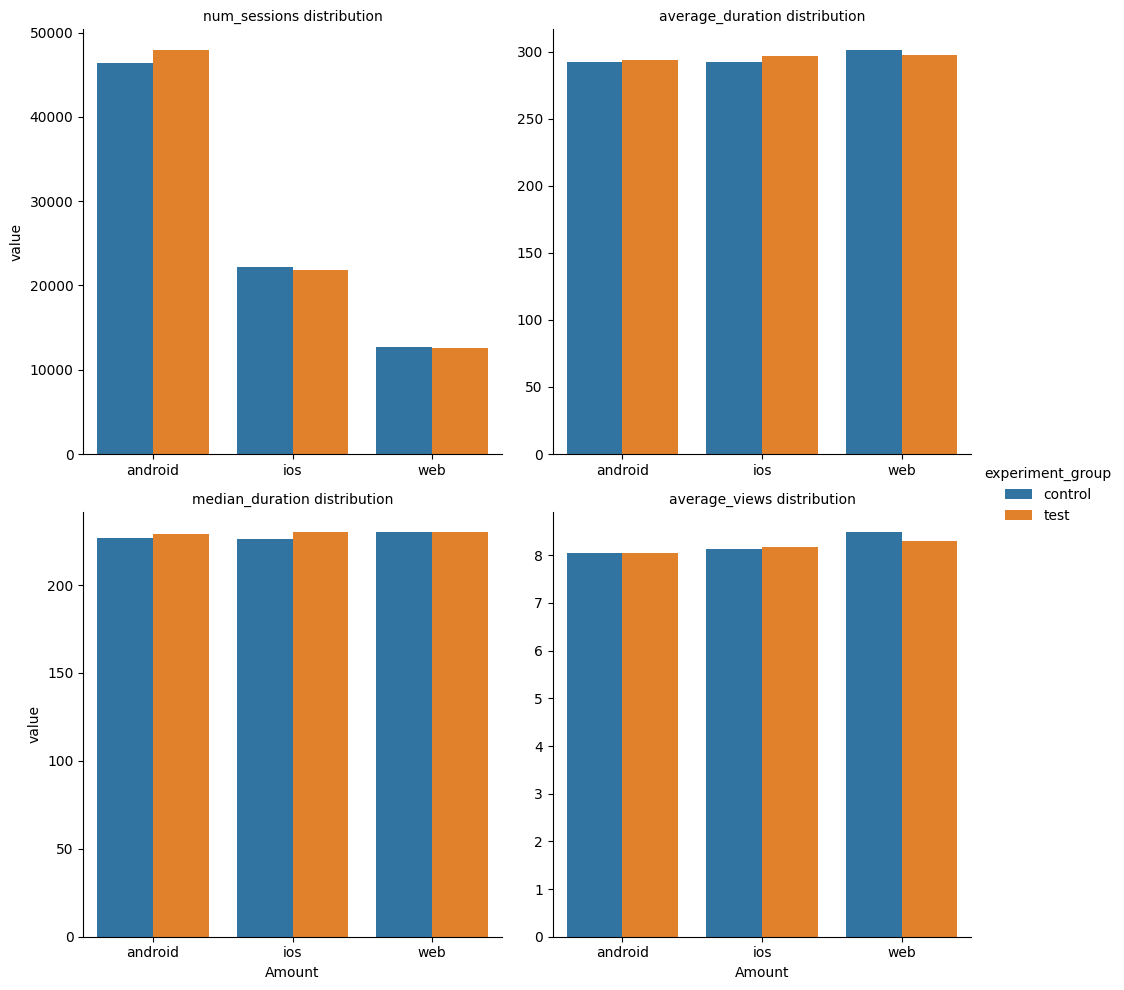

In [8]:
# Session quality

with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            SELECT 
                s.device,
                eu.experiment_group,
                COUNT(DISTINCT s.session_id) as num_sessions,
                AVG(s.session_duration_sec) as average_duration,
                PERCENTILE_CONT(0.5) 
                    WITHIN GROUP (ORDER BY s.session_duration_sec) as median_duration,
                AVG(s.page_views) as average_views
            FROM sessions s
            INNER JOIN experiment_assignment eu
                ON eu.user_id = s.user_id
            GROUP BY s.device, eu.experiment_group
        """),
        conn
    )

g = sns.catplot(
    x='device',
    y='value',
    data=result.melt(('device', 'experiment_group')),
    kind='bar',
    hue='experiment_group',
    col='variable',
    col_wrap=2,
    sharex=False,
    sharey=False
)

g.set_axis_labels(x_var='Amount')
g.set_titles('{col_name} distribution');

## **Funnel analysis**

The major improvment, that is set to test is the **increase in recommendation quality (i.e. CTR)**. Therefore the funnel analysis must be covered in order to prove the initial efficiency of the new model

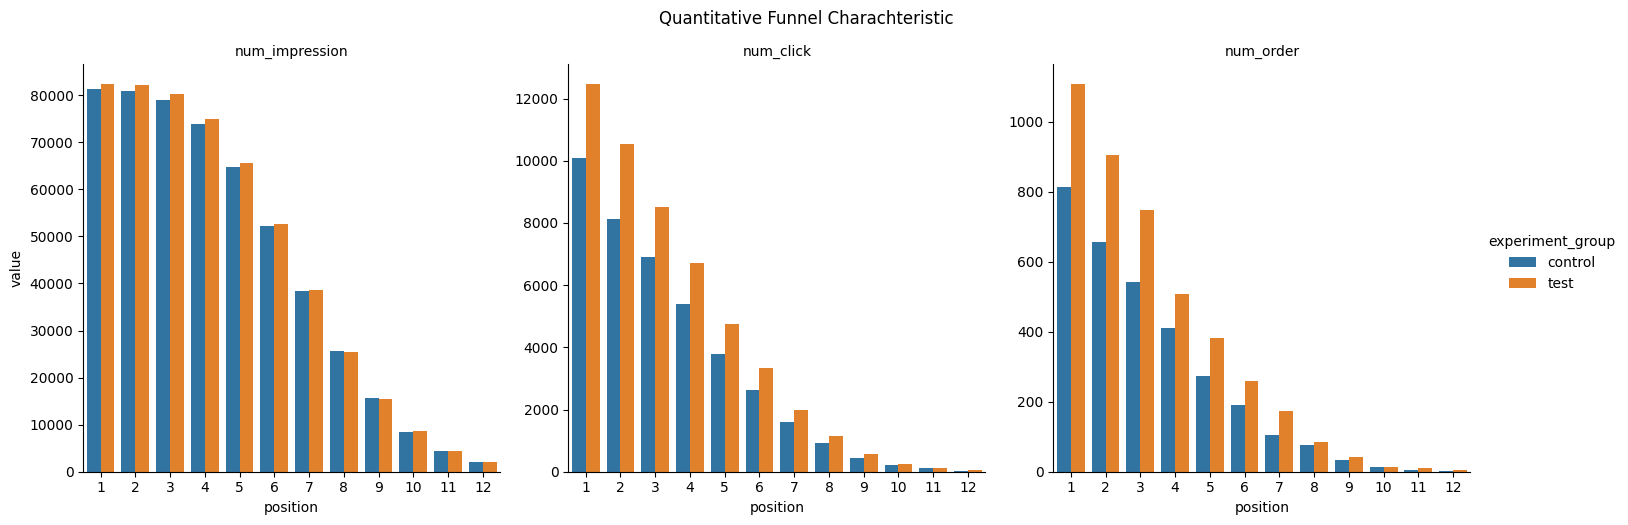

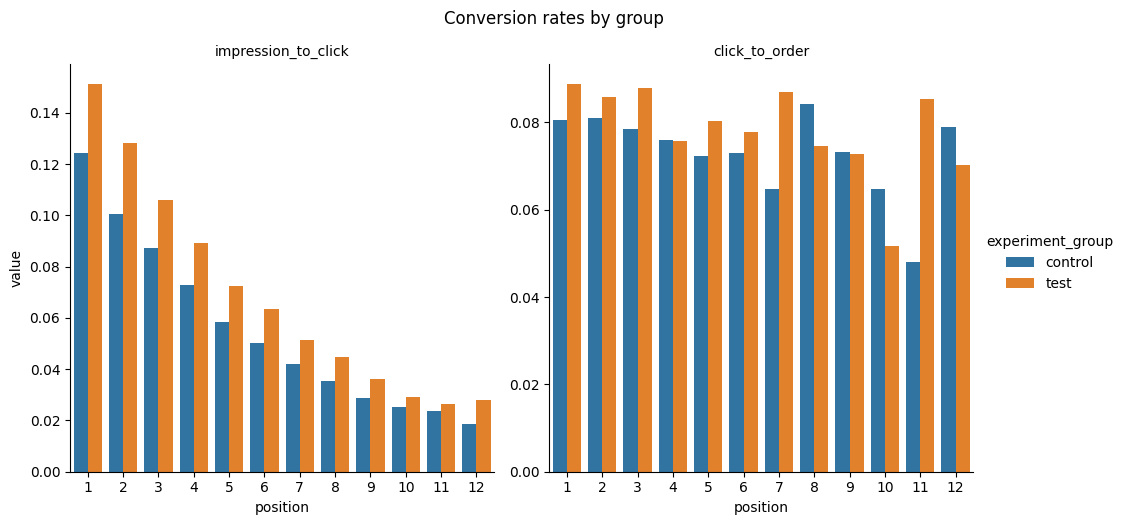

In [9]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            WITH funnel_data AS(
                SELECT
                    eu.experiment_group,
                    i.position,
                    COUNT(DISTINCT i.impression_id) as num_impression,
                    COUNT(DISTINCT c.click_id) as num_click,
                    COUNT(DISTINCT o.order_id) as num_order
                FROM impressions i
                LEFT JOIN clicks c
                    ON i.impression_id = c.impression_id
                LEFT JOIN orders o
                    ON o.click_id = c.click_id
                JOIN experiment_assignment eu
                    ON i.user_id = eu.user_id
                GROUP BY eu.experiment_group, i.position
            )
            SELECT
                *,
                num_click::float / num_impression as impression_to_click,
                num_order::float / num_click as click_to_order
            FROM funnel_data
        """), conn
    )

num_df = result[['experiment_group', 'position', 'num_impression', 'num_click', 'num_order']]

g1 = sns.catplot(
    data=num_df.melt(id_vars=('experiment_group', 'position')),
    hue='experiment_group',
    y='value',
    x='position',
    col='variable',
    kind='bar',
    sharey=False
)
g1.fig.suptitle('Quantitative Funnel Charachteristic', y=1.04)
g1.set_titles('{col_name}')


ratio_df = result[['experiment_group', 'position', 'impression_to_click', 'click_to_order']]
g2 = sns.catplot(
    data=ratio_df.melt(id_vars=('experiment_group', 'position')),
    hue='experiment_group',
    y='value',
    x='position',
    col='variable',
    kind='bar',
    sharey=False
)
g2.fig.suptitle('Conversion rates by group', y=1.04)
g2.set_titles('{col_name}');

From the funnel analysis it is visible, that the **overall number of clicks and therefore CTR** if the tested model **is higher** for every position of the card on the main screen (given that the base number of impressions is equal). We can also see some improvement in click-to-order conversion, though the effect is not as strong and stable as with CTR. 

According to the primary overview, the test model does indeed represent more value to business conversion-wise


Now let's dig into the mechanism and stability of new model's recommendations, to make sure that it doesn't prioriotizes any categories or lower-marginal products

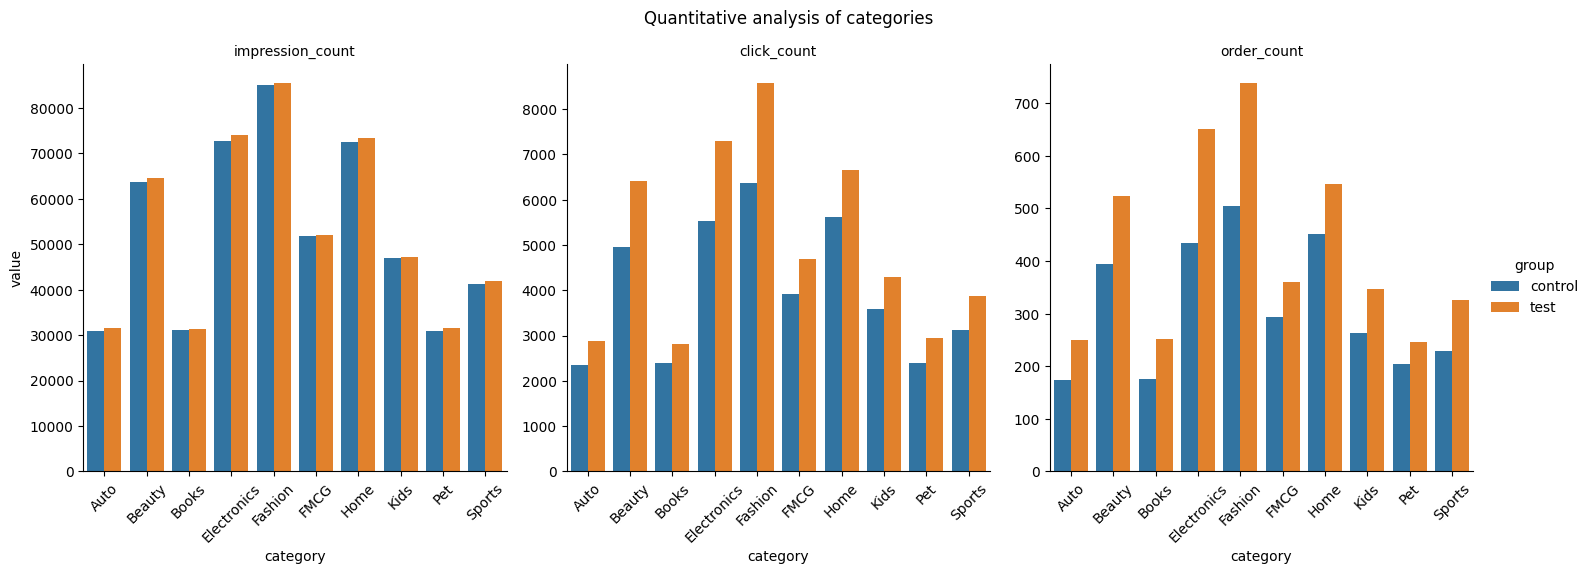

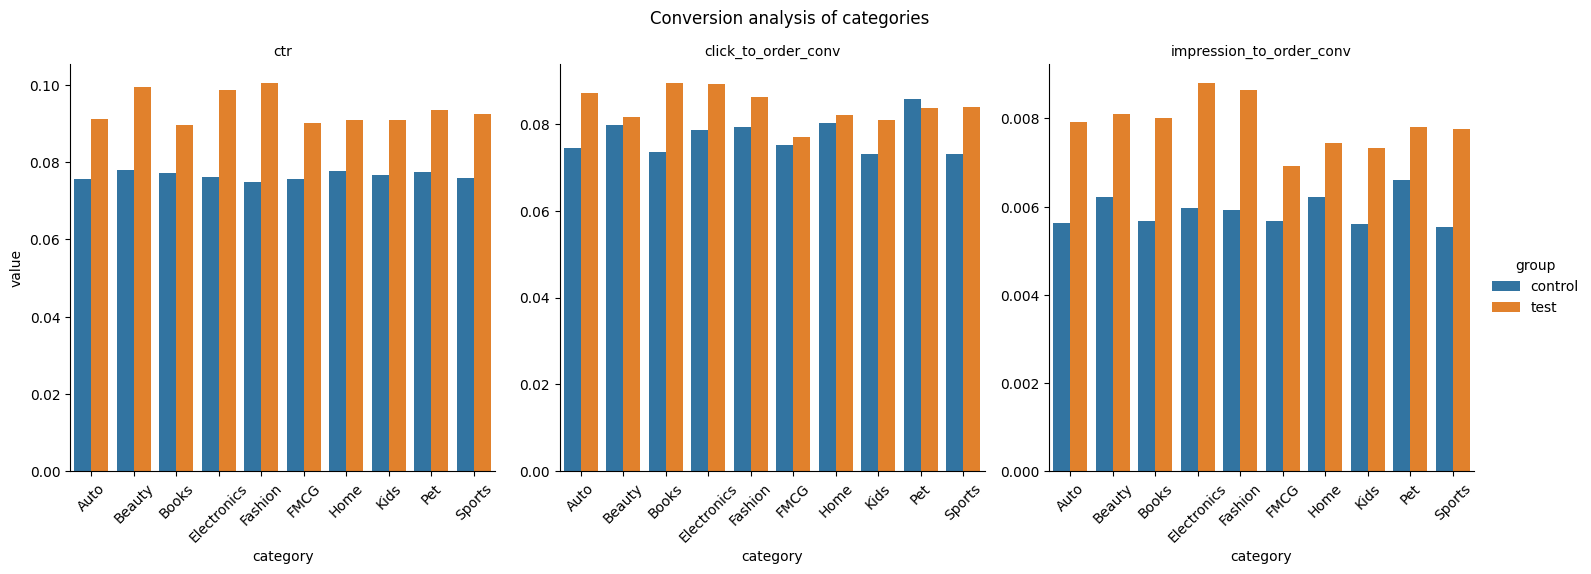

In [10]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            WITH cat_analysis AS (
                SELECT
                    ea.experiment_group as group,
                    p.category,
                    COUNT(DISTINCT i.impression_id) as impression_count,
                    COUNT(DISTINCT c.click_id) as click_count,
                    COUNT(DISTINCT o.order_id) as order_count
                FROM impressions i
                LEFT JOIN products p
                    ON i.product_id = p.product_id
                LEFT JOIN clicks c
                    ON i.impression_id = c.impression_id
                LEFT JOIN orders o
                    ON o.click_id = c.click_id
                JOIN experiment_assignment ea
                    ON i.user_id = ea.user_id
                GROUP BY ea.experiment_group, p.category
            )
            SELECT 
                *,
                click_count::float / NULLIF(impression_count, 0) as CTR,
                order_count::float / NULLIF(click_count, 0) as click_to_order_conv,
                order_count::float / NULLIF(impression_count, 0) as impression_to_order_conv
            FROM cat_analysis
        """), conn
    )

count_df = (result[['group', 'category', 'impression_count', 
                    'click_count', 'order_count']]
                    .melt(id_vars=('group', 'category')))
count_df
g1 = sns.catplot(
    data=count_df,
    x='category',
    y='value',
    col='variable',
    hue='group',
    kind='bar',
    sharey=False
)
g1.fig.suptitle('Quantitative analysis of categories', y=1.04)
g1.set_titles('{col_name}')
g1.set_xticklabels(rotation=45);

count_df = (result[['group', 'category', 'ctr',
                     'click_to_order_conv', 'impression_to_order_conv']]
                    .melt(id_vars=('group', 'category')))
count_df
g2 = sns.catplot(
    data=count_df,
    x='category',
    y='value',
    col='variable',
    hue='group',
    kind='bar',
    sharey=False
)
g2.fig.suptitle('Conversion analysis of categories', y=1.04)
g2.set_titles('{col_name}')
g2.set_xticklabels(rotation=45);

From these visualisations it is clear, that no categories are being prioriotized and the effect of CTR uplift is consistent troughout the whole catalogue

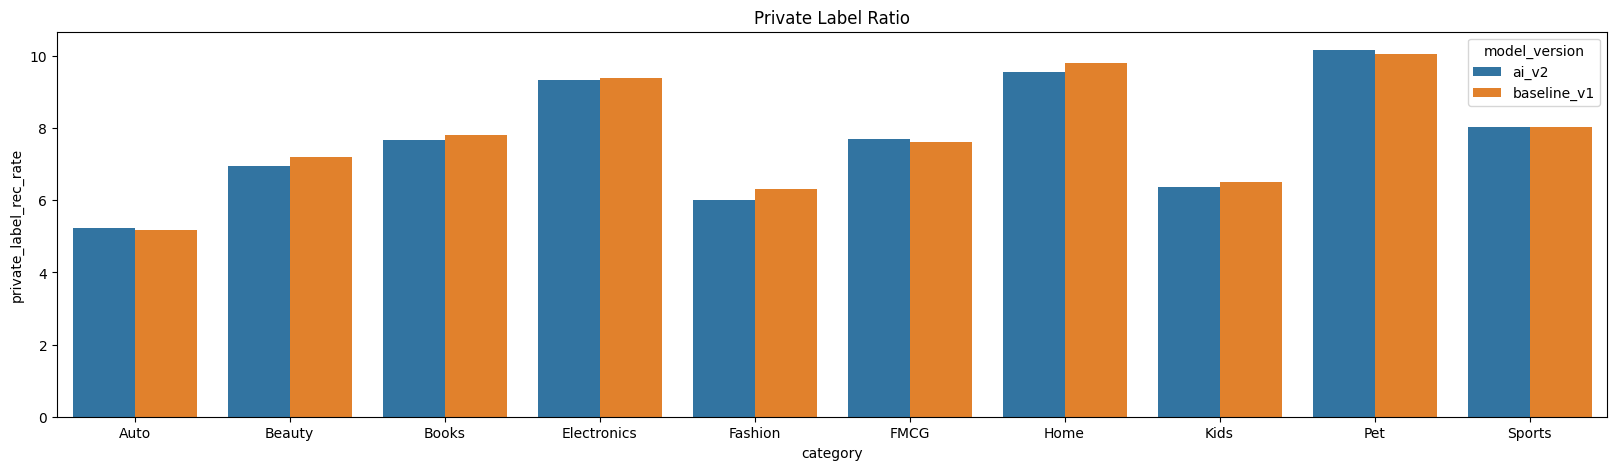

In [11]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            SELECT
                i.model_version,
                p.category,
                COUNT(*) as amount,
                AVG(p.is_private_label) * 100 as private_label_rec_rate,
                AVG(p.base_price_rub) as avg_price,
                AVG(p.base_price_rub * p.gross_margin_rate) as avg_gross_profit
            FROM impressions i
            JOIN products p
                ON p.product_id = i.product_id
            GROUP BY i.model_version, p.category
        """), conn
    )
result

plt.figure(figsize=(20, 5))
g = sns.barplot(
    data=result,
    x='category',
    y='private_label_rec_rate',
    hue='model_version'
)

g.set_title('Private Label Ratio');

Our tested model is unlikely to have any significant bias towards privately labaled products



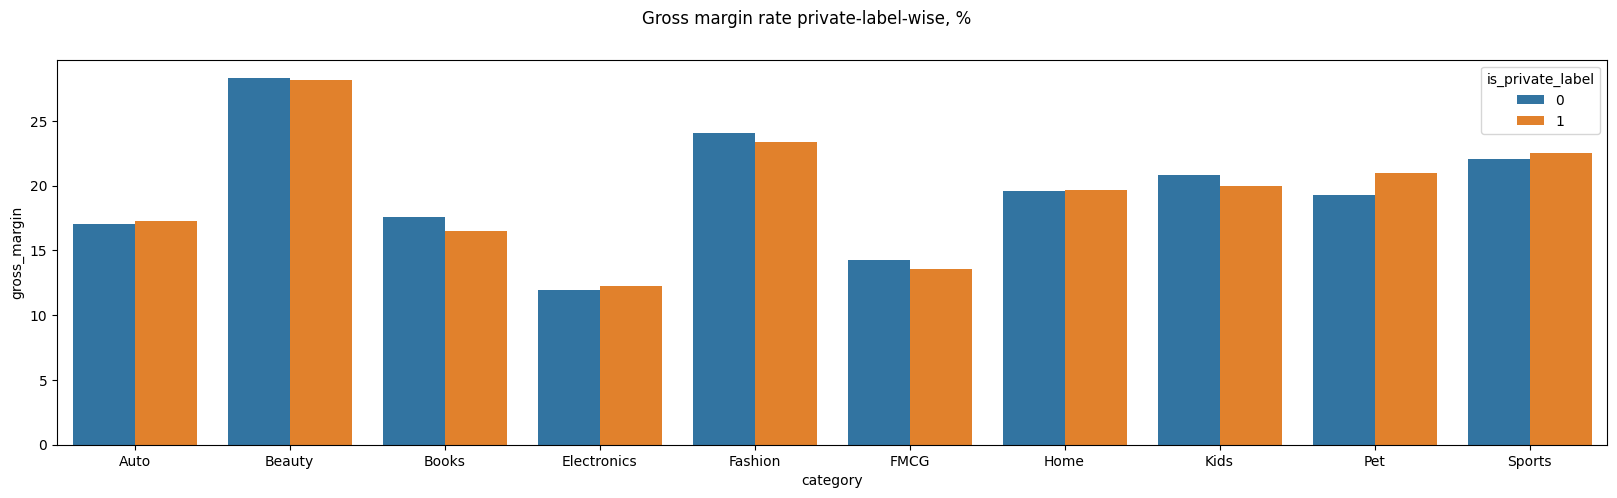

In [12]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            SELECT
                category,
                is_private_label,
                PERCENTILE_CONT(0.5) 
                    WITHIN GROUP (ORDER BY gross_margin_rate) * 100 as gross_margin
            FROM products
            GROUP BY category, is_private_label
        """), conn
    )

plt.figure(figsize=(20, 5))

g = sns.barplot(
    data=result,
    x='category',
    hue='is_private_label',
    y='gross_margin'
)

g.figure.suptitle('Gross margin rate private-label-wise, %');

There is no significant need to make the model more pro-private-label, because the gross margin doesn't correlate in any way with the affiliation with the company

## **Monetary value**
Now I need to analyse the monetary value of the model to make sure, that the total gross profit of the marketplace is fine

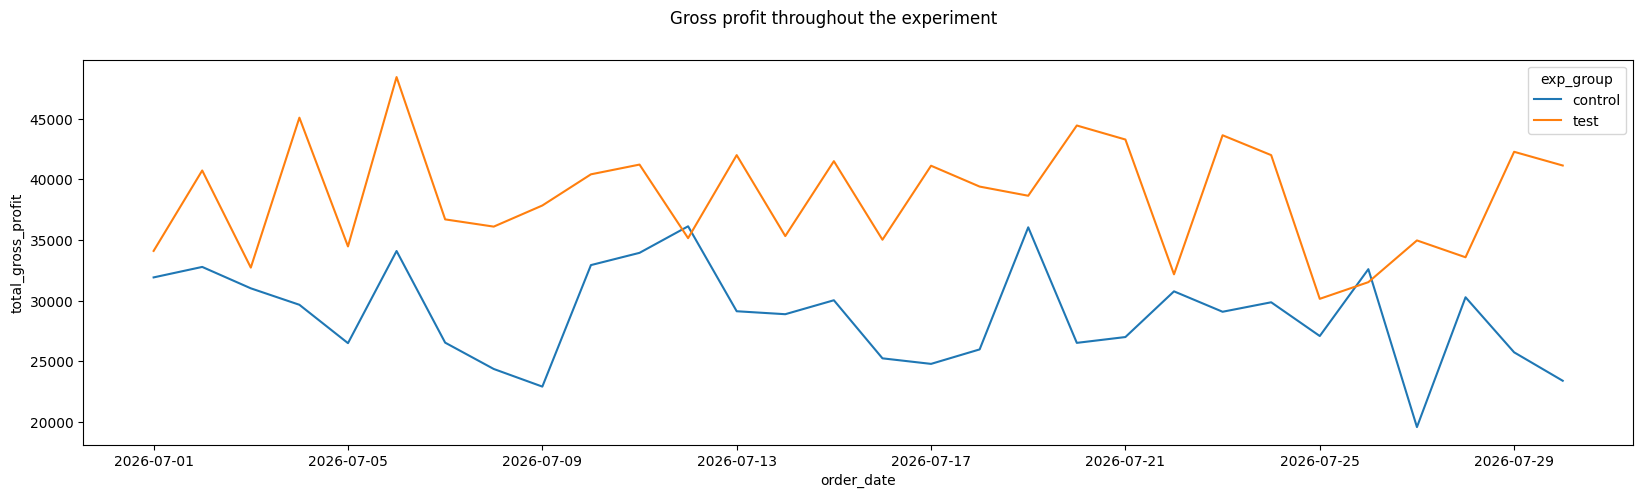

In [13]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            WITH order_stat AS (
                SELECT
                    ea.experiment_group as exp_group,
                    o.order_date,
                    COUNT(*) as user_traffic,
                    SUM(o.gross_margin_rub) as total,
                    AVG(o.is_returned) * 100 as return_rate
                FROM orders o
                JOIN experiment_assignment ea
                    ON ea.user_id = o.user_id
                GROUP BY ea.experiment_group, o.order_date
            )
            SELECT
                exp_group,
                order_date,
                user_traffic,
                EXTRACT (ISODOW FROM order_date),
                return_rate,
                total as total_gross_profit,
                AVG(total) OVER (
                    PARTITION BY exp_group
                    ORDER BY order_date
                    ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
                ) 
                / 
                NULLIF (
                    AVG(user_traffic) OVER (
                        PARTITION BY exp_group
                        ORDER BY order_date
                        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW),
                0) as rolling_7d_profit
            FROM order_stat
            ORDER BY exp_group, order_date
        """), conn
    )

plt.figure(figsize=(20, 5))
g = sns.lineplot(
    data=result,
    x='order_date',
    hue='exp_group',
    y='total_gross_profit'
)
g.figure.suptitle('Gross profit throughout the experiment');

The total gross profut of the new model is <span style="color: green"> **systematically higher than the baseline** </span>. It is definetely a good sign, but lets analyse the gross profit per user

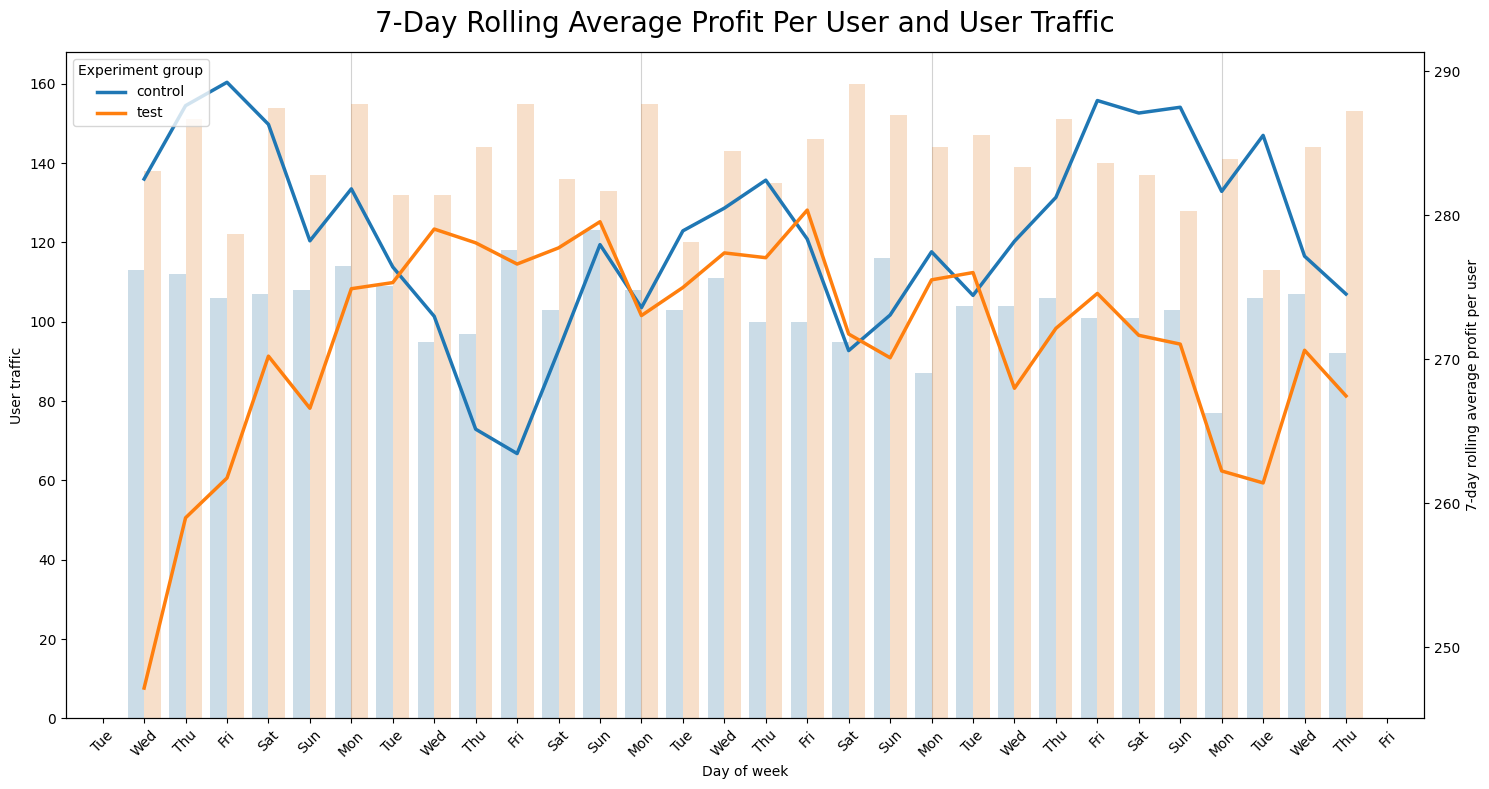

In [14]:
import matplotlib.dates as mdates

result['order_date'] = pd.to_datetime(result['order_date'])

fig, ax_traffic = plt.subplots(figsize=(15, 8))
ax_profit = ax_traffic.twinx()

sns.barplot(
    data=result,
    x='order_date',
    y='user_traffic',
    hue='exp_group',
    alpha=0.25,
    errorbar=None,
    native_scale=True,
    ax=ax_traffic
)

sns.lineplot(
    data=result,
    x='order_date',
    y='rolling_7d_profit',
    hue='exp_group',
    linewidth=2.5,
    ax=ax_profit
)

ax_traffic.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax_traffic.xaxis.set_major_formatter(mdates.DateFormatter('%a'))
ax_traffic.tick_params(axis='x', labelrotation=45)

mondays = (
    result.loc[
        result['order_date'].dt.weekday == 0,
        'order_date'
    ]
    .drop_duplicates()
)

for monday in mondays:
    ax_traffic.axvline(
        monday,
        color='gray',
        linewidth=0.8,
        alpha=0.35,
        zorder=0
    )

ax_traffic.set_xlabel('Day of week')
ax_traffic.set_ylabel('User traffic')
ax_profit.set_ylabel('7-day rolling average profit per user')

traffic_handles, traffic_labels = ax_traffic.get_legend_handles_labels()
profit_handles, profit_labels = ax_profit.get_legend_handles_labels()

ax_traffic.legend_.remove()
ax_profit.legend_.remove()

ax_profit.legend(
    profit_handles,
    profit_labels,
    title='Experiment group',
    loc='upper left'
)

fig.suptitle(
    '7-Day Rolling Average Profit Per User and User Traffic',
    fontsize=20
)

fig.tight_layout()
plt.show()

From this graph it is clear, that the gross profit per user tends to be higher in the baseline case. But it is also visible, that the **major value of the new model is a significantly superior order rate (barplot)**, that overcompensates the slight, non-systematic *drop in gross profit per user (lineplot)*.

## **Order quality**
Now let's analyse the order quality, how clients interact with the system after making an order

amount  ratio
group   is_returned               
control 0              2954  94.5%
        1               172   5.5%
test    0              3948  93.2%
        1               289   6.8%

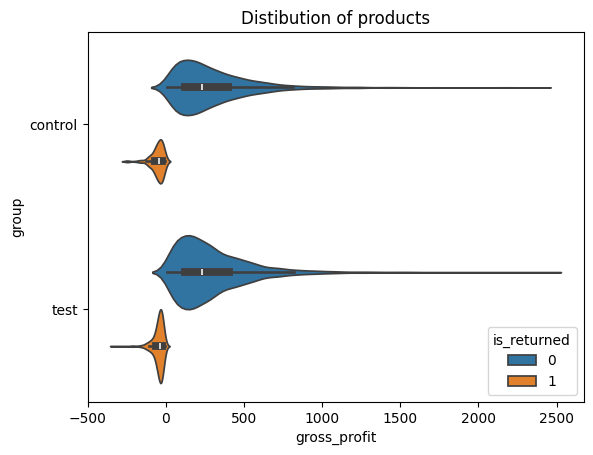

In [15]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            SELECT 
                ea.experiment_group as group,
                o.user_id,
                gross_margin_rub as gross_profit,
                is_returned
            FROM orders o
            JOIN experiment_assignment ea
                ON o.user_id = ea.user_id
        """), conn
    )


df = result.groupby(['group', 'is_returned']).agg(median=('gross_profit', 'median'), amount=('gross_profit', 'count'))

df['group_total'] = df.groupby('group')['amount'].transform('sum')
df['ratio'] = (df.amount / df.group_total * 100).map('{:.1f}%'.format)
display(df[['amount', 'ratio']])

g = sns.violinplot(
    data=result,
    y='group',
    x='gross_profit',
    hue='is_returned',
    density_norm='count'
);

g.set_title('Distibution of products');



The <span style="color: red;">**return rate has slightly increased**</span>, but <span style="color: green;">**the overall amount of the orders has increased**</span>. The returned order has a negative gross profit, that explains a slighly lower profit per user (this avg_based metric is quite sensitive towards lower outliers => drop in a metric).

**IMPORTANT: From this distribution plot it is clear, that the order amount growth is primarily driven by the increase in the number of low-medium gross proft products, this explains a lower per user and per order financial metrics. This drop is not a signal of a lowering efficiency, but rather a restructurisation of per-segment income**

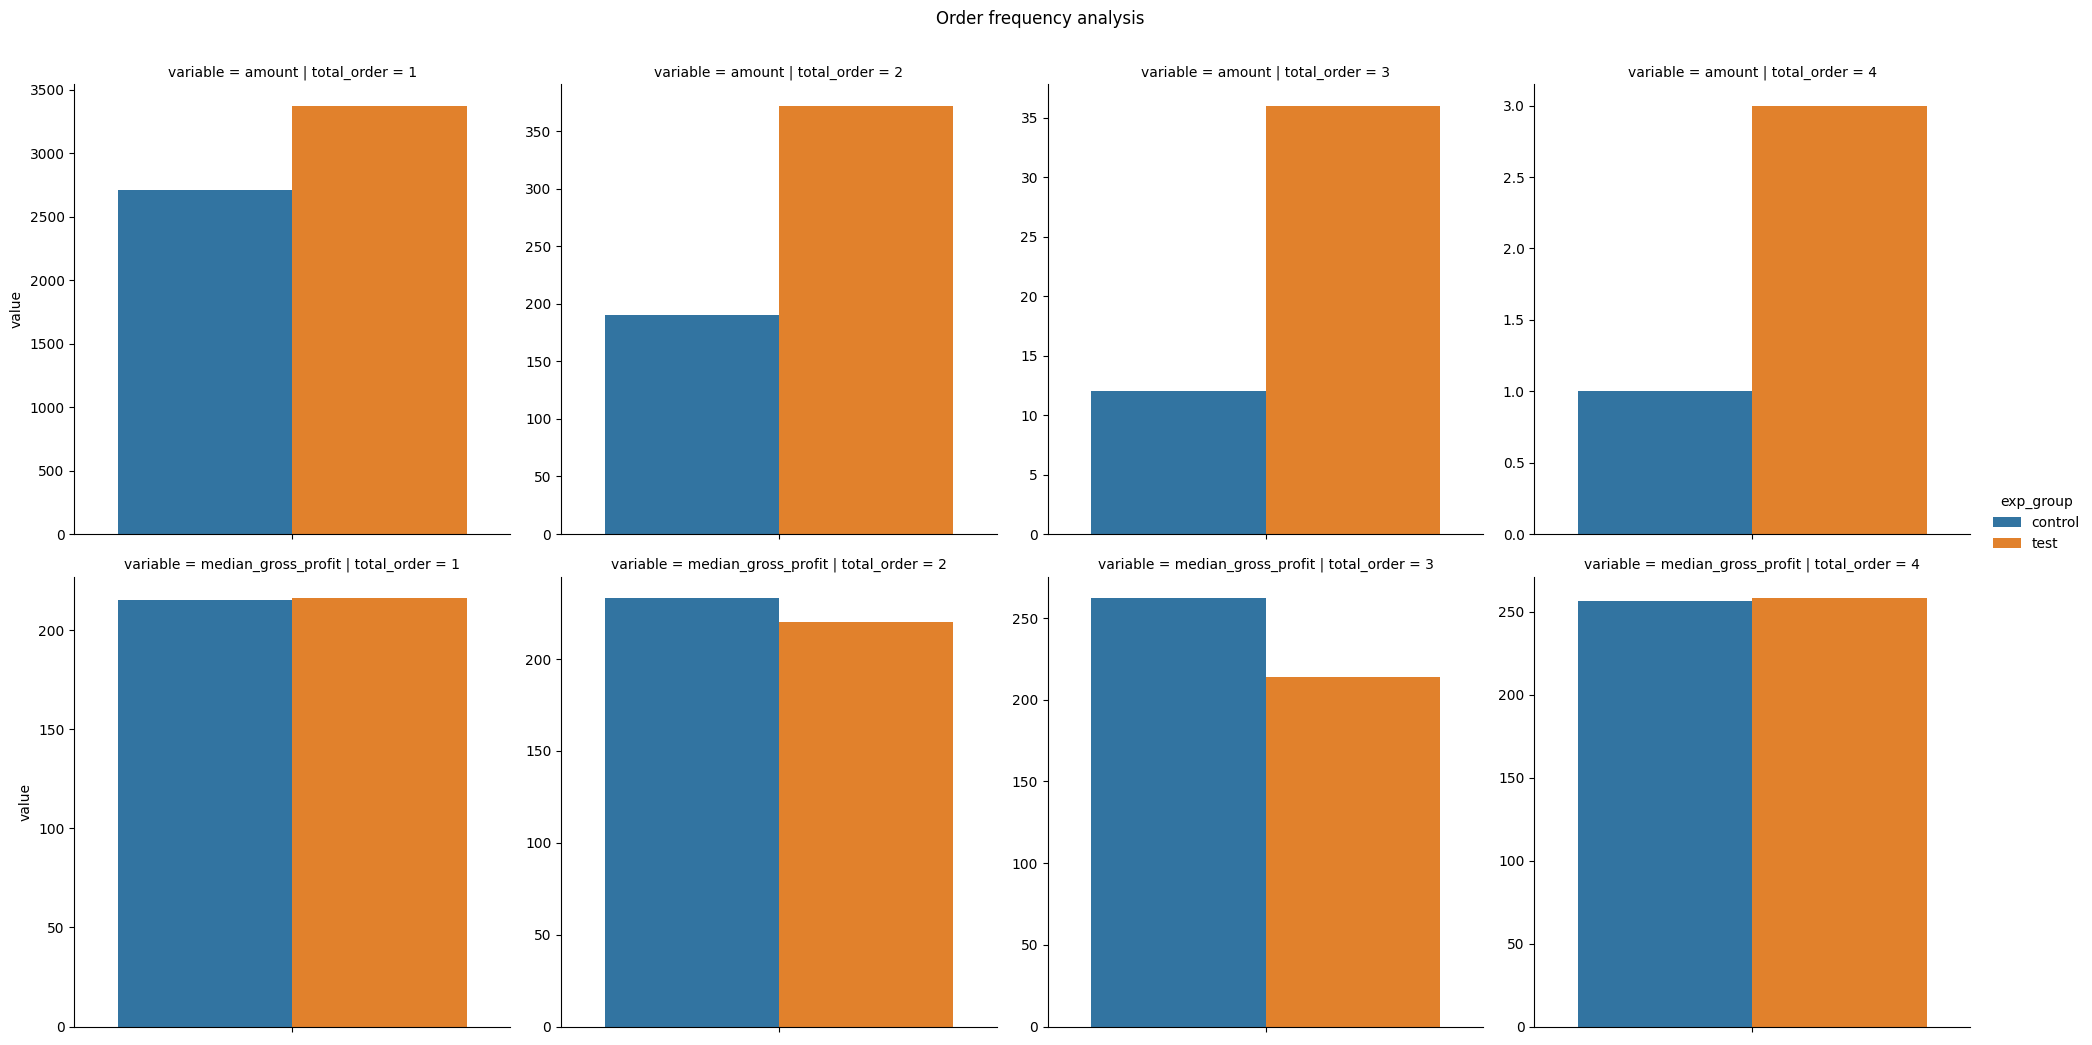

In [16]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            WITH order_dt AS (
                SELECT 
                    ea.experiment_group as exp_group,
                    o.user_id,
                    SUM(gross_margin_rub) as total_gross_profit,
                    COUNT(DISTINCT o.order_id) as total_order
                FROM orders o
                JOIN experiment_assignment ea
                    ON o.user_id = ea.user_id
                GROUP BY ea.experiment_group, o.user_id
            )
            SELECT 
                exp_group,
                total_order,
                PERCENTILE_CONT(0.5) WITHIN GROUP 
                    (ORDER BY total_gross_profit / NULLIF(total_order, 0)
                    ) as median_gross_profit,
                COUNT(user_id) as amount
            FROM order_dt
            GROUP BY exp_group, total_order
        """), conn
    )

g = sns.catplot(
    data=result.melt(id_vars=['exp_group', 'total_order']),
    y='value',
    hue='exp_group',
    col='total_order',
    row='variable',
    row_order=['amount', 'median_gross_profit'],
    kind='bar',
    sharey=False
)

g.figure.suptitle('Order frequency analysis', y=1.04);


The upside of the new model is the **clear trend of a bigger number of first, second and further orders**, despite a relatively **small drop in median gross profit per order**. That means, that recommendations are better and useers are likely to make new orders and stay with our service for longer, **potential increasing LTV**

C:\Users\BULOCHKA\AppData\Local\Temp\ipykernel_4908\63465795.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g=sns.barplot(
C:\Users\BULOCHKA\AppData\Local\Temp\ipykernel_4908\63465795.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels=result.category, rotation=45);


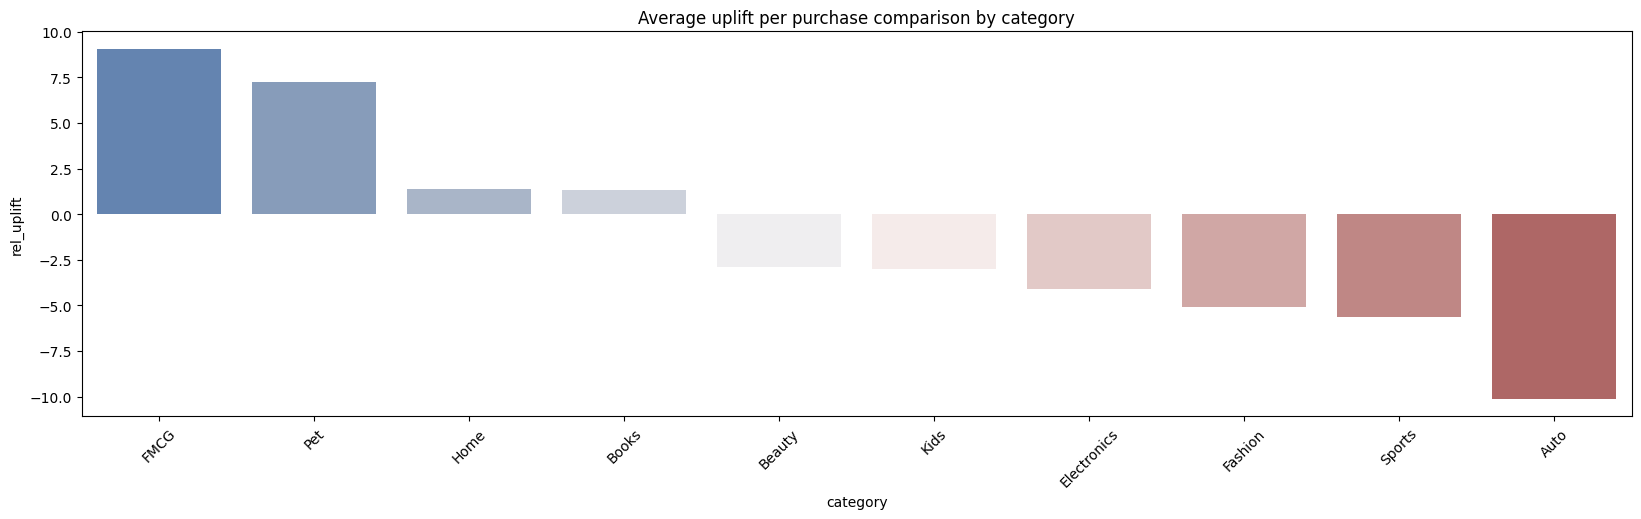

In [17]:
with engine.connect() as conn:
    result = pd.read_sql(
        text("""
            WITH cat_data AS (
                SELECT
                    ea.experiment_group as exp_group,
                    p.category,
                    AVG(o.gross_margin_rub) as avg_profit,
                    RANK() OVER (
                        PARTITION BY ea.experiment_group
                        ORDER BY AVG(o.gross_margin_rub) DESC
                    ) as rank
                FROM orders o
                JOIN products p
                    ON p.product_id = o.product_id
                JOIN experiment_assignment ea
                    ON o.user_id = ea.user_id
                GROUP BY ea.experiment_group, p.category
                ORDER BY exp_group, avg_profit DESC
            )
            SELECT
                c1.category,
                c1.avg_profit as avg_profit_control,
                c2.avg_profit as avg_profit_test,
                c2.avg_profit - c1.avg_profit as uplift,
                (c2.avg_profit - c1.avg_profit)::float / c1.avg_profit * 100 as rel_uplift,
                RANK() OVER(
                    ORDER BY (c2.avg_profit - c1.avg_profit)::float / c1.avg_profit * 100 DESC)
            FROM cat_data c1
            JOIN cat_data c2
                ON c1.category = c2.category
                    AND c2.exp_group='test'
                    AND c1.exp_group='control'
        """), conn
    )

plt.figure(figsize=(20, 5))

g=sns.barplot(
    data=result,
    y='rel_uplift',
    x='category',
    palette='vlag'
)

g.set_title('Average uplift per purchase comparison by category')
g.set_xticklabels(labels=result.category, rotation=45);

In [36]:
with engine.connect() as conn:
    result=pd.read_sql(
        text("""
            WITH order_dt AS (
                SELECT
                    ea.experiment_group,
                    st.reason,
                    COUNT(DISTINCT o.order_id) as total_orders,
                    COUNT(DISTINCT st.ticket_id) as total_tickets,
                    COUNT(DISTINCT st.ticket_id)::float 
                        / SUM(COUNT(DISTINCT o.order_id)) OVER (
                            PARTITION BY experiment_group) *100 as application_per_100orders,
                    AVG(resolved_within_24h) as resolve_rate
                FROM orders o
                JOIN experiment_assignment ea
                    ON ea.user_id = o.user_id
                LEFT JOIN support_tickets st
                    ON st.order_id = o.order_id
                        AND st.reason IN ('product_quality', 'recommendation_quality')
                GROUP BY ea.experiment_group, st.reason
            )
            SELECT
                *
            FROM order_dt
        """), conn
    )

result

,experiment_group,reason,total_orders,total_tickets,application_per_100orders,resolve_rate
0,control,product_quality,46,46,1.471529,0.695652
1,control,recommendation_quality,12,12,0.383877,0.750000
2,control,None,3068,0,0.000000,NaN
3,test,product_quality,69,69,1.628511,0.739130
4,test,recommendation_quality,11,11,0.259618,1.000000
5,test,None,4157,0,0.000000,NaN


The number of support application due to product and reccomendation quality is low and doesn't vary much among test and control group. If we take recommendation quality alone, there is not enough data to detect any difference

# **3. Hypothesis testing**

In [38]:
with engine.connect() as conn:
    users = pd.read_sql(text('SELECT * FROM users'), conn)
    experiment_assignment = pd.read_sql(text('SELECT * FROM experiment_assignment'), conn)
    sessions = pd.read_sql(text('SELECT * FROM sessions'), conn)
    impressions = pd.read_sql(text('SELECT * FROM impressions'), conn)
    clicks = pd.read_sql(text('SELECT * FROM clicks'), conn)
    orders = pd.read_sql(text('SELECT * FROM orders'), conn)
    products = pd.read_sql(text('SELECT * FROM products'), conn)
    support_tickets = pd.read_sql(text('SELECT * FROM support_tickets'), conn)

<Axes: >

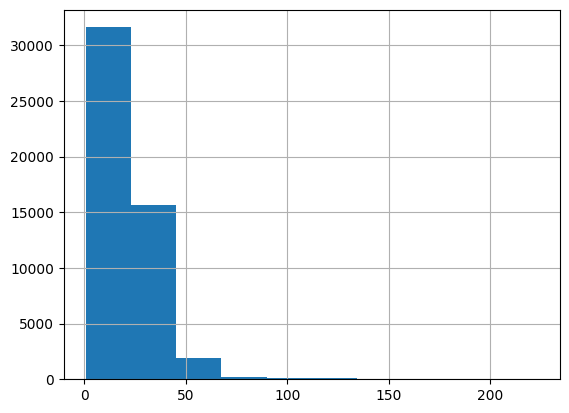

In [42]:
shows = impressions.merge(experiment_assignment, on='user_id', how='inner')
shows = shows.groupby('user_id').agg('size')
shows.hist()